<a href="https://colab.research.google.com/github/RenadAlh/CaliforniaHousingML/blob/main/california_housing_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**California Housing | Classification & Regression**

This notebook works with the **California Housing** dataset (20,640 rows, 8 features) was made to explore two supervised learning tasks:

1. **Classification**: predict whether a house is "expensive" (above the median price) using **Logistic Regression**, benchmarked against a **Random Forest** classifier.
2. **Regression**: predict the actual median house value using **Polynomial Regression (degree 2)**, benchmarked against a plain **Linear Regression** baseline.


**Contents**
1. Data Exploration and Preprocessing
2. Logistic Regression for Classification (+ Random Forest comparison)
3. Non-linear Regression (+ Linear baseline comparison)
<br>

By: **Renad Alharthi** & **Rawan Alahmadi**

##1. Data Exploration and Preprocessing

------------------------------------------

####1) Load the California Housing dataset from scikit-learn

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and convert to a pandas DataFrame
housing_data = fetch_california_housing(as_frame=True)
housing_df = housing_data.frame

# Check the number of rows and columns
num_rows, num_columns = housing_df.shape

print(f'Number of rows: {num_rows}')
print(f'Number of columns: {num_columns}')

Number of rows: 20640
Number of columns: 9


####2) Perform basic exploratory data analysis (EDA)

In [ ]:
housing_df.head(10)  # Display the first 10 rows

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
housing_df.isnull().sum()  # Check if there are any missing values


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
housing_df.describe()  # Show mean, median, and standard deviation for numerical columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


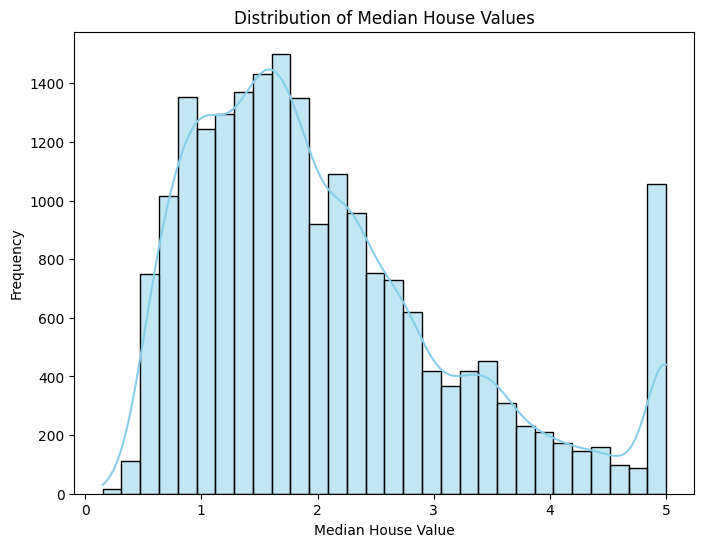

In [ ]:
# Histogram of Median House Values
plt.figure(figsize=(8, 6))
sns.histplot(housing_df['MedHouseVal'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()



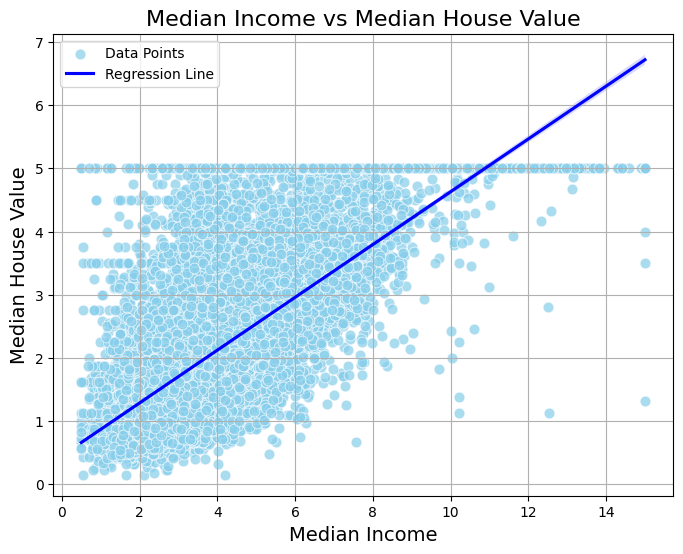

In [ ]:
# Scatter Plot: Median Income vs Median House Value
plt.figure(figsize=(8, 6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=housing_df, alpha=0.7, color='skyblue', s=60, label='Data Points')  # Adjust point size and transparency

# Add a regression line for better visualization of the trend
sns.regplot(x='MedInc', y='MedHouseVal', data=housing_df, scatter=False, color='blue', label='Regression Line')

plt.title('Median Income vs Median House Value', fontsize=16)
plt.xlabel('Median Income', fontsize=14)
plt.ylabel('Median House Value', fontsize=14)
plt.legend()
plt.grid(True)  # Add grid lines for better readability
plt.show()


####3) Explore feature correlations

A correlation heatmap helps flag multicollinearity before modeling and hints at which features are likely to matter most.

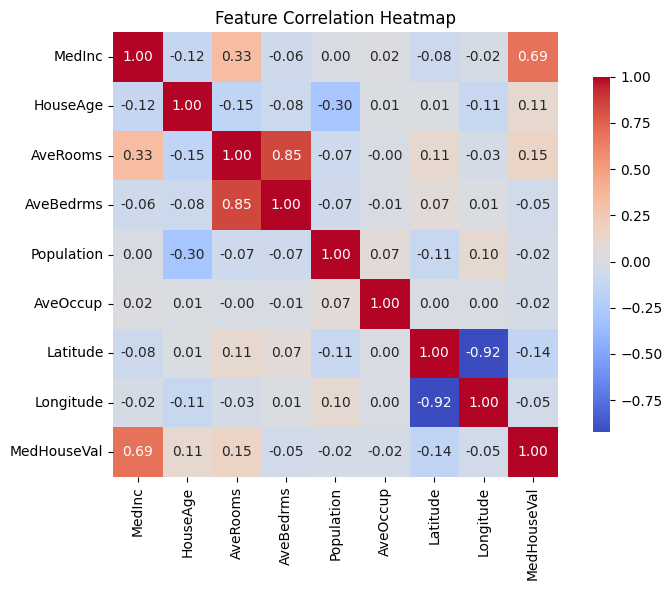

In [ ]:
# Correlation heatmap across all features (including the target)
plt.figure(figsize=(8, 6))
corr = housing_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


####4) Preprocess the data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data for better performance (optional) - excluding the target variable 'MedHouseVal'
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(housing_df.drop(columns=['MedHouseVal'])),
                 columns=housing_df.drop(columns=['MedHouseVal']).columns)

# Define the target variable (classification)
median_house_value = housing_df['MedHouseVal'].median()
y = (housing_df['MedHouseVal'] > median_house_value).astype(int)

##2. Logistic Regression for Classification
--------

####1) Split the data into training and testing sets (use 80% for training, 20% for testing).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Split the data into training and testing sets (use 80% for training, 20% for testing).

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

####2) Train a logistic regression model to predict whether a house is 'expensive' or 'not expensive'.

In [ ]:

# Define the logistic regression model with class_weight='balanced' to handle class imbalance
logistic = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

# Define the hyperparameter grid for regularization strength 'C'
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize GridSearchCV for hyperparameter tuning with 5-fold cross-validation
grid_search = GridSearchCV(logistic, param_grid, cv=5, scoring='accuracy')

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_logistic_model = grid_search.best_estimator_

print("\nBest Hyperparameter (C):", grid_search.best_params_['C'])


Best Hyperparameter (C): 10


####3) Make predictions on the test set

In [ ]:
# Predict on the test data
y_pred = best_logistic_model.predict(X_test)


####4) Evaluate the model's performance

In [ ]:
# Calculate accuracy score
test_accuracy = accuracy_score(y_test, y_pred)
print("\nTest Set Accuracy:", test_accuracy)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Get a detailed classification report (precision, recall, F1-score)
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_auc)

# Cross-validation accuracy
cv_scores = cross_val_score(best_logistic_model, X_train, y_train, cv=5)
print("Cross-validated Accuracy:", cv_scores.mean())





Test Set Accuracy: 0.8263081395348837

Confusion Matrix:
 [[1720  357]
 [ 360 1691]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      2077
           1       0.83      0.82      0.83      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128

ROC-AUC Score: 0.8262966712809867
Cross-validated Accuracy: 0.829941577990238


####5) Use confusion matrices and ROC curves to visually represent model performance.

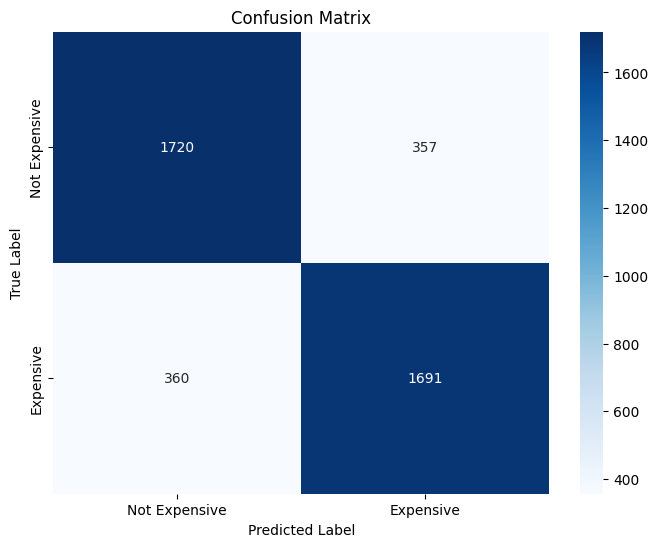

In [ ]:
# Confusion Matrix Heatmap with Pink Color
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Expensive', 'Expensive'],
            yticklabels=['Not Expensive', 'Expensive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


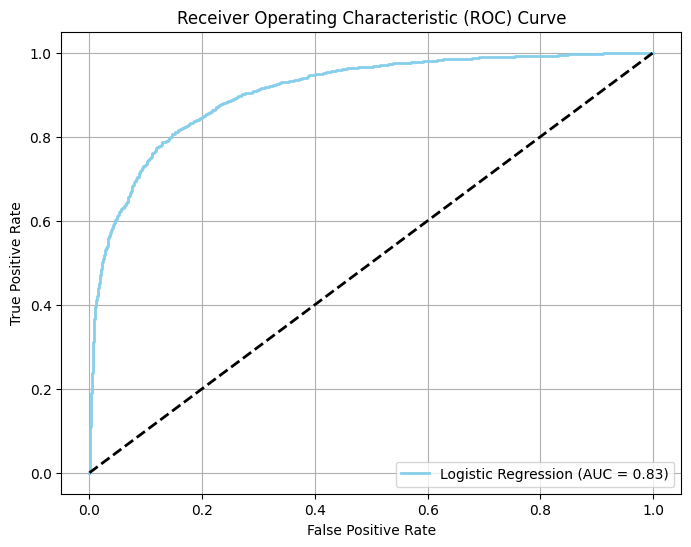

In [ ]:
# ROC Curve
y_prob = best_logistic_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})', color='Skyblue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)  # Diagonal line for random guessing
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



####6) Compare against a Random Forest classifier

Logistic Regression assumes a roughly linear decision boundary. To check whether a non-linear model captures the data better, we trained a Random Forest with the same train/test split and compare accuracy, F1-score, and ROC-AUC side by side.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Train a Random Forest classifier as a stronger, non-linear benchmark
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Test Accuracy:", rf_accuracy)
print("Random Forest F1-score:", rf_f1)
print("Random Forest ROC-AUC:", rf_roc_auc)


Random Forest Test Accuracy: 0.8968023255813954
Random Forest F1-score: 0.8955370279548799
Random Forest ROC-AUC: 0.961099098646526


####7) Side-by-side model comparison

,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.826308,0.825079,0.826297
1,Random Forest,0.896802,0.895537,0.961099


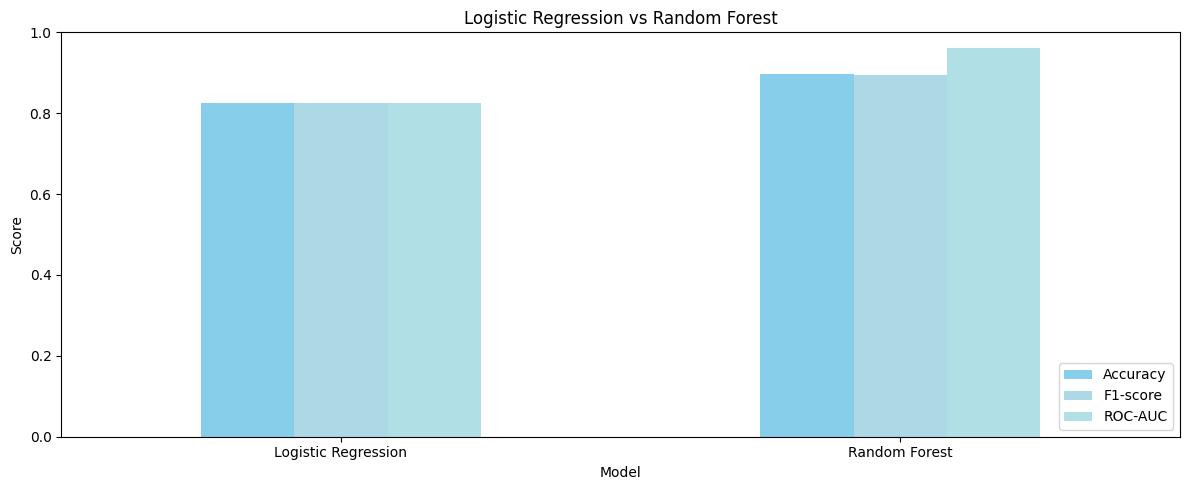

In [ ]:
# Compare Logistic Regression vs Random Forest on the same test set
logistic_f1 = f1_score(y_test, y_pred)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [test_accuracy, rf_accuracy],
    'F1-score': [logistic_f1, rf_f1],
    'ROC-AUC': [roc_auc, rf_roc_auc],
})
display(comparison_df)

comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 5), color=['skyblue', 'lightblue', 'powderblue'])
plt.title('Logistic Regression vs Random Forest')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


####8) Feature importance (Random Forest)

Random Forest gives a built-in importance score per feature, useful for sanity-checking which variables are actually driving predictions.

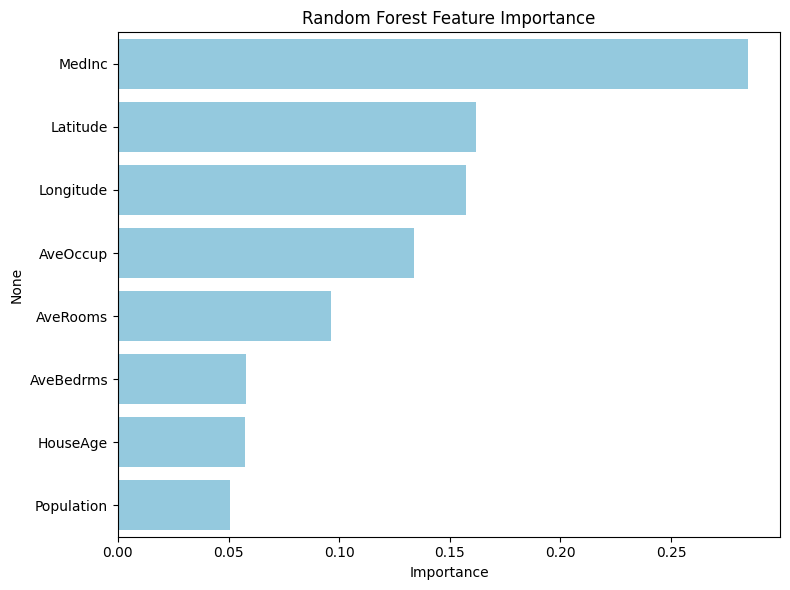

In [ ]:
# Plot Random Forest feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


##3. Non-linear Regression
----


####1) For this task, we used the continuous target variable (house prices).

####2) Implement a polynomial regression model of degree 2 to predict house prices.

####3) Split the data into training and testing sets (use 80% for training, 20% for testing).

####4) Train the model and make predictions on the test set.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create polynomial features for degree 2
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

# Split the data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, housing_df['MedHouseVal'], test_size=0.2, random_state=42)

# Train the polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

# Make predictions
y_pred_poly = poly_model.predict(X_test_poly)

####5) Baseline comparison: plain Linear Regression vs Polynomial (degree 2)

Before trusting the polynomial model, it's worth checking how much the degree-2 expansion actually buys us over a plain linear fit on the same features.

In [ ]:
# Plain linear regression baseline on the un-expanded features
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X, housing_df['MedHouseVal'], test_size=0.2, random_state=42
)
linear_model = LinearRegression()
linear_model.fit(X_train_lin, y_train_lin)
y_pred_lin = linear_model.predict(X_test_lin)

mse_lin = mean_squared_error(y_test_lin, y_pred_lin)
r2_lin = r2_score(y_test_lin, y_pred_lin)

print("Linear Regression  -> MSE: {:.4f}, R2: {:.4f}".format(mse_lin, r2_lin))


Linear Regression  -> MSE: 0.5559, R2: 0.5758


####6) Evaluate the model's performance using

In [ ]:
# Calculate mean squared error (MSE)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)

# Calculate R-squared score
r2_poly = r2_score(y_test_poly, y_pred_poly)

# Print evaluation results
print("Polynomial Regression-> MSE: {:.4f}, R2: {:.4f}".format(mse_poly,r2_poly))


Polynomial Regression-> MSE: 0.4643, R2: 0.6457


####7) Compare Linear Regression vs Polynomial Regression

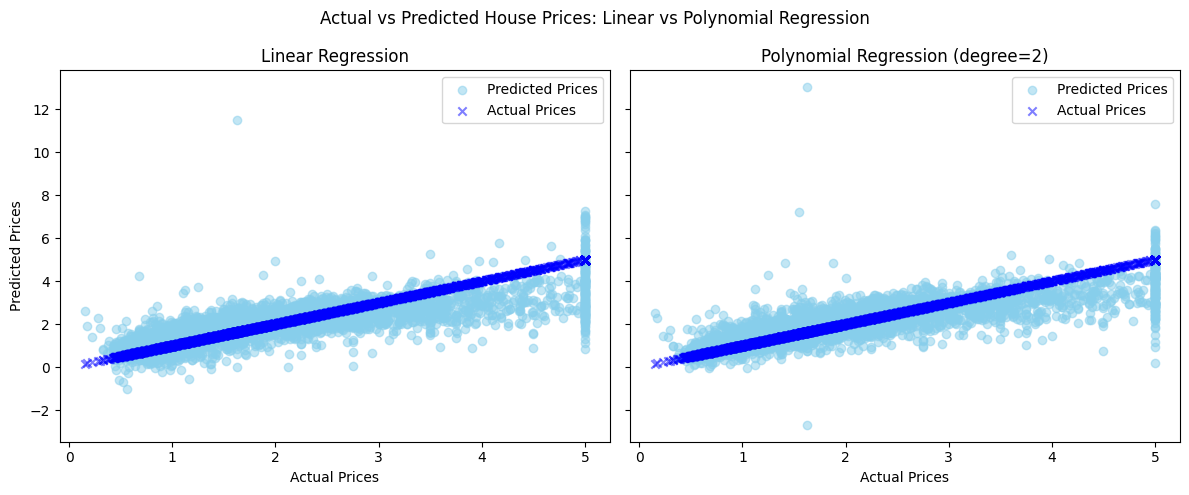

In [ ]:
# Actual vs Predicted: Linear Regression baseline vs Polynomial Regression, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.5, color='skyblue', label='Predicted Prices')
axes[0].scatter(y_test_lin, y_test_lin, alpha=0.5, color='blue', label='Actual Prices', marker='x')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual Prices')
axes[0].set_ylabel('Predicted Prices')
axes[0].legend()

axes[1].scatter(y_test_poly, y_pred_poly, alpha=0.5, color='skyblue', label='Predicted Prices')
axes[1].scatter(y_test_poly, y_test_poly, alpha=0.5, color='blue', label='Actual Prices', marker='x')
axes[1].set_title('Polynomial Regression (degree=2)')
axes[1].set_xlabel('Actual Prices')
axes[1].legend()

plt.suptitle('Actual vs Predicted House Prices: Linear vs Polynomial Regression')
plt.tight_layout()
plt.show()


A residual plot (errors vs. predicted value) is a quick way to spot whether the model is systematically over- or under-predicting at certain price ranges.

In [ ]:
# Compare the two regression models
reg_comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (deg=2)'],
    'MSE': [mse_lin, mse_poly],
    'R2': [r2_lin, r2_poly],
})
display(reg_comparison_df)


,Model,MSE,R2
0,Linear Regression,0.555892,0.575788
1,Polynomial Regression (deg=2),0.464302,0.645682
